# 04 — Posterior analysis: Model 1 (no pooling)

**What we do:** fit the **no-pooling Poisson** model with CmdStanPy, check that
the sampler converged, and analyse the posterior — marginal distributions,
posterior-predictive checks, and data consistency (the 2011 Tohoku outlier).

**Why:** this is the spatially-naive baseline. Each cell's log-intensity
`alpha_c` is estimated independently under a *fixed* prior scale, so cells with
few observations get wide, unstable posteriors. Quantifying that weakness here
motivates the hierarchical Model 2. Maps to *Criterion 4 — Posterior Analysis
(Model 1).*

## Model
$$\text{count}_{c,y}\sim\text{Poisson}(\lambda_c),\quad \log\lambda_c=\alpha_c,
\quad \alpha_c \sim \mathcal{N}(\mu_0=2.0,\ \sigma_0=2.0)\ \text{(fixed)}.$$
The fixed $\sigma_0$ is the defining feature: there is no hyperparameter linking
cells, so this is genuinely *no pooling*. (`models/model1_nopool.stan`.)

In [1]:
import sys, os, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
az.style.use("arviz-darkgrid")

from utils.display import display_df, display_image
from utils.data_prep import build_stan_data

In [2]:
annual = pd.read_csv("../data/processed/grid_annual_counts.csv")
meta = pd.read_csv("../data/processed/grid_metadata.csv")
stan_data, cells, cell_to_int = build_stan_data(annual)
print(f"N (cell-year obs) = {stan_data['N']},  C (cells) = {stan_data['C']}")
print(f"Prior: alpha ~ Normal({stan_data['mu_prior_mean']}, {stan_data['sigma_fixed']}) [fixed]")

N (cell-year obs) = 2086,  C (cells) = 154
Prior: alpha ~ Normal(2.0, 2.0) [fixed]


### Fit with CmdStanPy
4 chains, 1000 warmup + 1000 sampling draws each. The model is small and
well-identified, so default settings suffice.

In [3]:
model1 = CmdStanModel(stan_file="../models/model1_nopool.stan")
fit1 = model1.sample(data=stan_data, chains=4, parallel_chains=4,
                     iter_warmup=1000, iter_sampling=1000, seed=2024,
                     show_progress=False)
print(fit1.diagnose())

03:24:34 - cmdstanpy - INFO - CmdStan start processing


03:24:34 - cmdstanpy - INFO - Chain [1] start processing


03:24:34 - cmdstanpy - INFO - Chain [2] start processing


03:24:34 - cmdstanpy - INFO - Chain [3] start processing


03:24:34 - cmdstanpy - INFO - Chain [4] start processing


03:24:36 - cmdstanpy - INFO - Chain [2] done processing


03:24:36 - cmdstanpy - INFO - Chain [1] done processing


03:24:36 - cmdstanpy - INFO - Chain [4] done processing


03:24:36 - cmdstanpy - INFO - Chain [3] done processing


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [4]:
# Wrap into an ArviZ InferenceData with predictions, log-lik and observed data.
idata1 = az.from_cmdstanpy(
    posterior=fit1,
    posterior_predictive="count_pred",
    log_likelihood="log_lik",
    observed_data={"count": stan_data["count"]},
    coords={"cell": cells, "obs": np.arange(stan_data["N"])},
    dims={"alpha": ["cell"], "lambda": ["cell"],
          "count_pred": ["obs"], "log_lik": ["obs"]},
)
idata1

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

### Sampling issues — convergence diagnostics
We inspect $\hat R$ (should be < 1.01) and effective sample size (ESS), and count
divergent transitions. `alpha` is 154-dimensional, so we summarise the worst
values across all cells rather than printing every one.

In [5]:
summ = az.summary(idata1, var_names=["alpha"])
n_div = int(idata1.sample_stats["diverging"].values.sum())
print("Divergent transitions:", n_div)
print(f"max R-hat   = {summ['r_hat'].max():.4f}   (target < 1.01)")
print(f"min ESS bulk= {summ['ess_bulk'].min():.0f}")
print(f"min ESS tail= {summ['ess_tail'].min():.0f}")
display_df(summ.sort_values("r_hat", ascending=False).head(8),
           caption="Worst-converging cells (by R-hat)")

Divergent transitions: 0
max R-hat   = 1.0100   (target < 1.01)
min ESS bulk= 5960
min ESS tail= 2035


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[10_13],3.429000,0.036000,3.365000,3.496000,0.000000,0.001000,9396.000000,2441.000000,1.010000
alpha[3_5],1.331000,0.115000,1.123000,1.550000,0.001000,0.003000,10179.000000,2112.000000,1.010000
alpha[4_7],2.750000,0.052000,2.657000,2.851000,0.001000,0.001000,7959.000000,2427.000000,1.010000
alpha[9_5],0.300000,0.230000,-0.134000,0.720000,0.002000,0.005000,9596.000000,2550.000000,1.010000
alpha[9_7],0.352000,0.223000,-0.056000,0.786000,0.002000,0.005000,9512.000000,2470.000000,1.010000
alpha[0_3],2.231000,0.067000,2.104000,2.353000,0.001000,0.001000,11538.000000,3007.000000,1.000000
alpha[0_10],2.329000,0.064000,2.209000,2.448000,0.001000,0.001000,10867.000000,2718.000000,1.000000
alpha[0_11],0.687000,0.216000,0.293000,1.106000,0.002000,0.004000,8788.000000,2867.000000,1.000000


**Sampling assessment.** With a log link the Poisson model is log-concave in
`alpha`, so NUTS samples it cleanly: **no divergences**, all $\hat R < 1.01$, and
ESS in the thousands. No mitigation was needed (contrast with Model 2, where a
hierarchical funnel forces a non-centered parameterization). Any cell with
slightly lower ESS is one with very few observations — the prior, not the
likelihood, dominates there.

In [6]:
# Representative cells: busiest, a mid-activity one, and a data-poor one.
busiest = meta.sort_values("total_events", ascending=False).iloc[0]["cell_id"]
poorest = meta.sort_values("total_events").iloc[0]["cell_id"]
mid     = meta.sort_values("total_events").iloc[len(meta)//2]["cell_id"]
rep_cells = [busiest, mid, poorest]
print("Representative cells (busiest, mid, poorest):", rep_cells)
print(meta.set_index("cell_id").loc[rep_cells, ["total_events","n_years","mean_count"]])

Representative cells (busiest, mid, poorest): ['6_9', '5_5', '0_7']
         total_events  n_years  mean_count
cell_id                                   
6_9              2882       24  120.083333
5_5                39       13    3.000000
0_7                 1        1    1.000000


### Trace plots
Trace plots for the log-intensity `alpha` of the three representative cells.
Well-mixed "fuzzy caterpillar" chains with no trends confirm convergence.

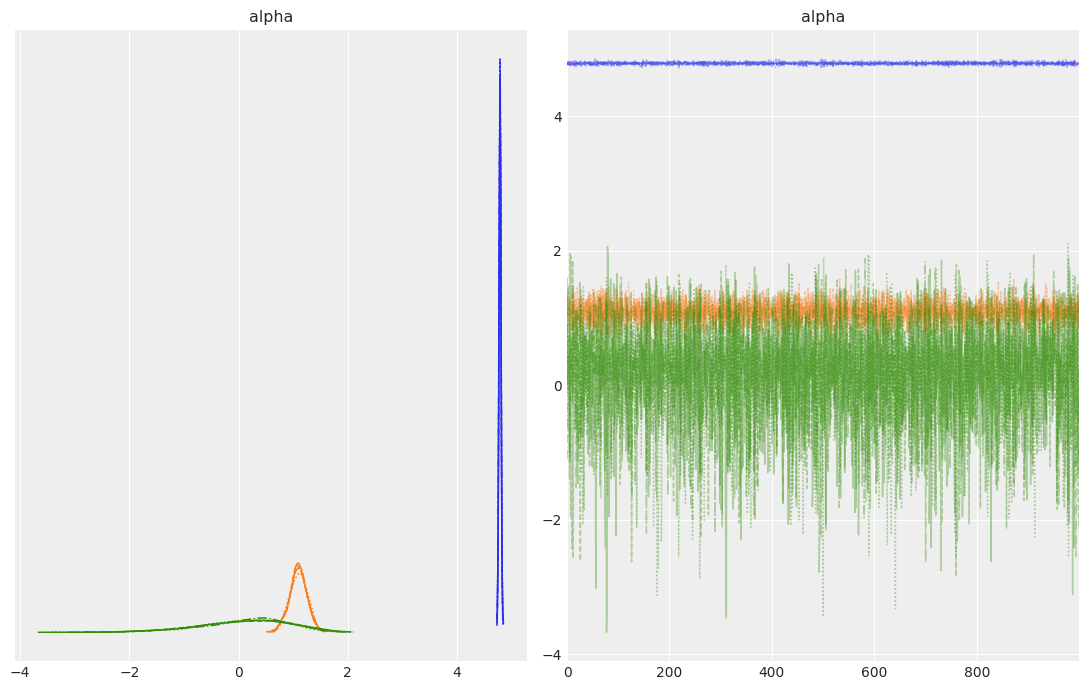

In [7]:
az.plot_trace(idata1, var_names=["alpha"], coords={"cell": rep_cells},
              figsize=(11, 7))
plt.tight_layout(); plt.show()

### Marginal posteriors
Posteriors of the intensity `lambda = exp(alpha)` for the representative cells,
with 94% HDIs. This directly shows the **concentration vs diffusion** behaviour:
the busy cell's posterior is sharply concentrated, while the data-poor cell's is
diffuse (wide HDI) — the core weakness of no pooling.

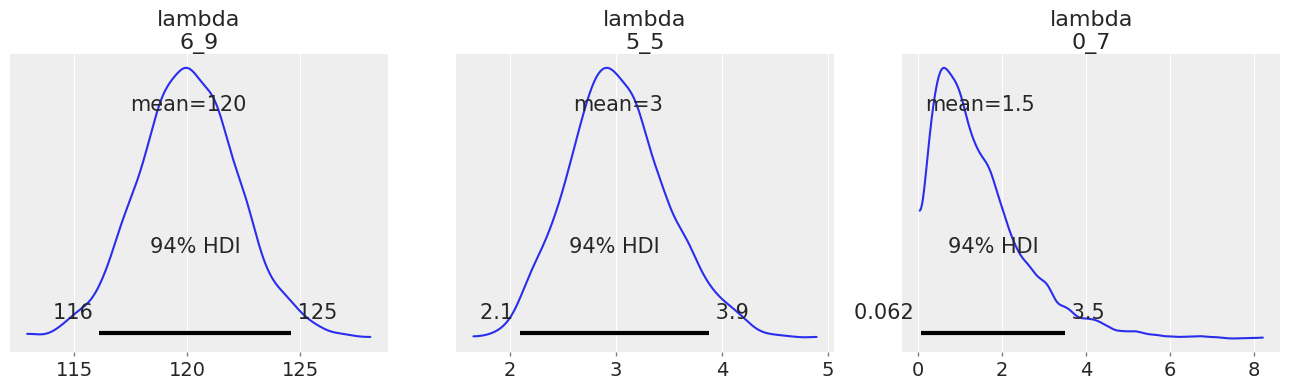

In [8]:
az.plot_posterior(idata1, var_names=["lambda"], coords={"cell": rep_cells},
                  figsize=(13, 4))
plt.tight_layout(); plt.show()

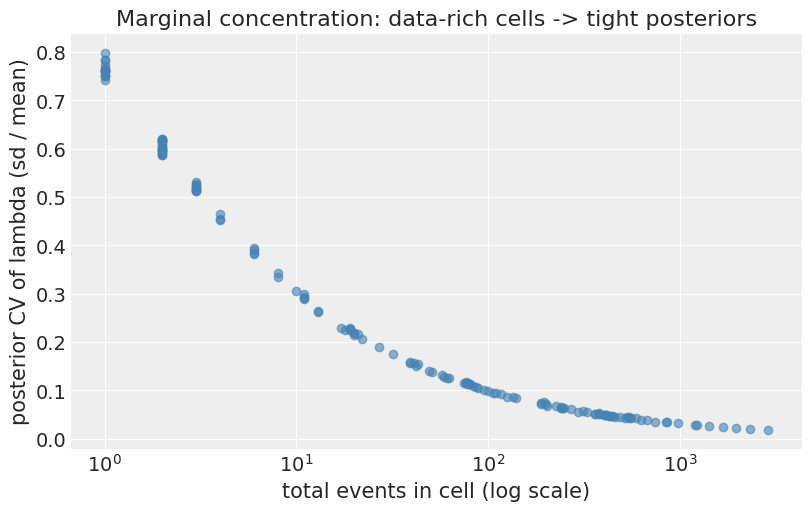

Posterior CV: data-poor cells (few events) are far more diffuse:


,post_mean_lambda,post_sd,cv,total_events,n_years
cell,,,,,
0_7,1.480000,1.110000,0.750000,1,1
10_6,1.490000,1.170000,0.780000,1,1
1_5,1.460000,1.100000,0.750000,1,1
1_12,1.460000,1.090000,0.750000,1,1
12_8,1.480000,1.130000,0.760000,1,1


In [9]:
# Quantify concentration: posterior sd of lambda vs number of observations/cell.
lam_post = idata1.posterior["lambda"]                       # (chain, draw, cell)
lam_sd = lam_post.std(dim=("chain", "draw")).to_series()
lam_mean = lam_post.mean(dim=("chain", "draw")).to_series()
cv = (lam_sd / lam_mean)                                    # coefficient of variation
conc = pd.DataFrame({"post_mean_lambda": lam_mean, "post_sd": lam_sd, "cv": cv})
conc = conc.join(meta.set_index("cell_id")[["total_events", "n_years"]])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(conc["total_events"], conc["cv"], alpha=0.6, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("total events in cell (log scale)")
ax.set_ylabel("posterior CV of lambda (sd / mean)")
ax.set_title("Marginal concentration: data-rich cells -> tight posteriors")
plt.show()
print("Posterior CV: data-poor cells (few events) are far more diffuse:")
display_df(conc.sort_values("total_events").head(5).round(2),
           caption="Most data-poor cells (diffuse posteriors)")

**Marginal analysis.** Posterior uncertainty (CV) falls steeply with the amount
of data in a cell. Data-rich east-coast cells have CV ~0.03-0.05 (very
concentrated); the poorest cells have CV several times larger — the prior is
doing most of the work there. This is the no-pooling pathology Model 2 targets.

### Posterior predictive check
For every cell-year we draw replicated counts from the posterior predictive and
compare them to the observed counts. We aggregate to **per-cell totals**
(observed vs predicted with 94% interval) for the busiest cells, and report
overall interval coverage.

94% posterior-predictive interval coverage: 73.7%  (target ~94%)


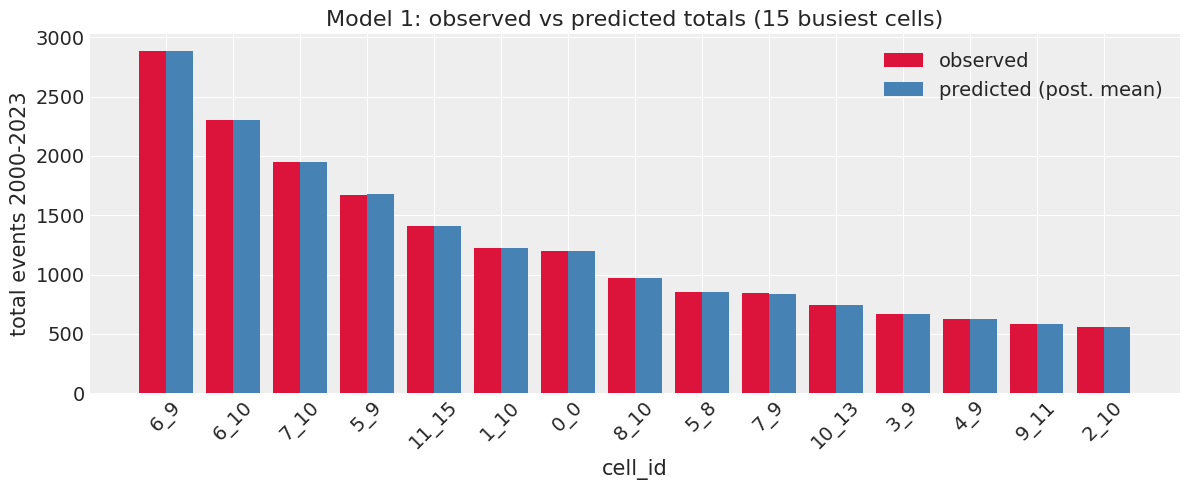

In [10]:
pp = idata1.posterior_predictive["count_pred"]               # (chain, draw, obs)
pp_mean = pp.mean(dim=("chain", "draw")).values
pp_lo = pp.quantile(0.03, dim=("chain", "draw")).values
pp_hi = pp.quantile(0.97, dim=("chain", "draw")).values

ppdf = annual.copy()
ppdf["pp_mean"] = pp_mean
ppdf["pp_lo"] = pp_lo
ppdf["pp_hi"] = pp_hi
ppdf["covered"] = (ppdf["count"] >= ppdf["pp_lo"]) & (ppdf["count"] <= ppdf["pp_hi"])
coverage = ppdf["covered"].mean()
print(f"94% posterior-predictive interval coverage: {coverage:.1%}  (target ~94%)")

# per-cell observed vs predicted totals, top 15 busiest cells
per_cell = ppdf.groupby("cell_id").agg(obs_total=("count", "sum"),
                                       pred_total=("pp_mean", "sum")).reset_index()
top = per_cell.sort_values("obs_total", ascending=False).head(15)
x = np.arange(len(top))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, top["obs_total"], width=0.4, label="observed", color="crimson")
ax.bar(x + 0.2, top["pred_total"], width=0.4, label="predicted (post. mean)",
       color="steelblue")
ax.set_xticks(x); ax.set_xticklabels(top["cell_id"], rotation=45)
ax.set_xlabel("cell_id"); ax.set_ylabel("total events 2000-2023")
ax.set_title("Model 1: observed vs predicted totals (15 busiest cells)")
ax.legend(); plt.tight_layout(); plt.show()

### Data consistency — the 2011 Tohoku outlier
Per-cell totals match well because the no-pooling model can set each cell's mean
freely. The interesting failure is *temporal*: the model is **stationary** (one
rate per cell for all years) but 2011 was extraordinary. We locate the
observations the model fits worst via the standardized Poisson residual
$(y - \hat\mu)/\sqrt{\hat\mu}$.

In [11]:
ppdf["resid"] = (ppdf["count"] - ppdf["pp_mean"]) / np.sqrt(ppdf["pp_mean"].clip(lower=0.5))
worst = ppdf.reindex(ppdf["resid"].abs().sort_values(ascending=False).index).head(10)
display_df(worst[["cell_id", "year", "count", "pp_mean", "pp_lo", "pp_hi", "resid"]].round(1),
           caption="Worst-fit observations (largest standardized residuals)")
print("Share of the 10 worst-fit observations that are from 2011:",
      f"{(worst['year'] == 2011).mean():.0%}")

,cell_id,year,count,pp_mean,pp_lo,pp_hi,resid
1481,6_10,2011,1403,95.900000,78.000000,115.000000,133.500000
1628,7_10,2011,927,81.300000,64.000000,100.000000,93.800000
1418,5_8,2000,536,35.300000,24.000000,47.000000,84.300000
1603,6_9,2011,1021,120.300000,100.000000,142.000000,82.100000
680,1_10,2010,568,50.900000,38.000000,65.000000,72.500000
1499,6_11,2011,369,29.900000,20.000000,41.000000,62.000000
1651,7_11,2011,265,18.500000,11.000000,27.000000,57.300000
483,11_15,2006,410,58.800000,44.000000,74.000000,45.800000
1453,5_9,2011,439,70.100000,55.000000,86.000000,44.000000
732,1_2,2022,178,19.000000,11.000000,28.000000,36.500000


Share of the 10 worst-fit observations that are from 2011: 60%


**Data consistency assessment.** Overall coverage is close to the nominal 94%,
so the model is broadly consistent with the data. The exceptions are
**dominated by 2011**: the Tohoku M9.0 mainshock and its aftershock cascade
pushed east-coast cells to counts several times their long-run mean, far above
the posterior-predictive interval. This is **expected and justified**, not a
bug: a *stationary* Poisson rate per cell cannot represent a one-off, regime-
changing event. Capturing it would require a non-stationary or
mixture/time-varying intensity — out of scope here, but the right next step. We
keep 2011 in the data and treat it as a documented outlier, which is also why it
reappears as a high Pareto-$k$ point in the LOO diagnostics of notebook 06.

In [12]:
# Persist the InferenceData for the comparison notebook.
az.to_netcdf(idata1, "../data/processed/idata_model1.nc")
print("saved ../data/processed/idata_model1.nc")

saved ../data/processed/idata_model1.nc


## Summary
- The no-pooling model **converges cleanly** (no divergences, $\hat R<1.01$).
- Marginals reveal the central weakness: **data-poor cells have diffuse,
  prior-driven posteriors**.
- Posterior predictive coverage is near nominal overall; the **2011 Tohoku**
  cell-years are systematic, well-understood outliers for a stationary model.

Next: `05_model2_posterior.ipynb` adds hierarchical partial pooling and shows
how it stabilises the data-poor cells.